In [1]:
import joblib
import mlflow
import pandas as pd
import os
import sys
from interpret import show

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

from sklearn.metrics import confusion_matrix
sys.path.append(os.path.dirname(os.getcwd()))
from models.interface import model_interface
from data.DataLoader import DataLoader

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Retail Project")

<Experiment: artifact_location='./mlruns/1', experiment_id='1', lifecycle_stage='active', name='Retail Project', tags={}>

In [2]:
def find_mlruns_parent():
        """Search upward from current directory for a folder containing 'mlruns'."""
        current = os.path.abspath(".")
        while True:
                if os.path.exists(os.path.join(current, "mlruns")):
                        return current
                parent = os.path.dirname(current)
                if parent == current:
                        break
                current = parent
        raise FileNotFoundError("Could not find 'mlruns' directory. Please specify the path manually.")

mlruns_parent = find_mlruns_parent()

In [3]:
model_names = [
            "Logistic Regression",
            "XGBoost Classifier",
            "XGBoost Binary Classifier"
]

latest_runs = {}

for model_name in model_names:
        runs = mlflow.search_runs(
                experiment_names=["Retail Project"],
                filter_string=f"tags.task = 'classification' AND tags.model_name = '{model_name}' AND attribute.status = 'FINISHED'",
                order_by=["attribute.start_time DESC"],
                max_results=1,
        )

        if runs.empty:
                print(f"No run found for {model_name}")
                continue
        latest_runs[model_name] = runs.iloc[0]
        print(latest_runs[model_name])

run_id                                            b52a1fbfbec44c30ac7e9bfa0aa4e4f0
experiment_id                                                                    1
status                                                                    FINISHED
artifact_uri                     ./mlruns/1/b52a1fbfbec44c30ac7e9bfa0aa4e4f0/ar...
start_time                                        2026-09-02 15:13:35.398000+00:00
end_time                                          2026-09-02 15:13:36.564000+00:00
metrics.test_accuracy                                                      0.63099
metrics.train_accuracy                                                    0.635215
metrics.train_recall                                                      0.635215
metrics.test_recall                                                        0.63099
metrics.train_precision                                                   0.590226
metrics.test_f1                                                           0.515539
metr

In [4]:
models = {}
metrics_summary = []
for model_name, run in latest_runs.items():
    run_id = run.run_id
    
    # 1. Load the model
    model_file = os.path.join(mlruns_parent, "mlruns", "1", run_id, "artifacts", "model", "model.joblib")
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model file not found: {model_file}")
    model = joblib.load(model_file)
    
    # 2. Get run metadata from MLflow
    mlflow_run = mlflow.get_run(run_id)
    
    # 3. Extract metrics (e.g., rmse, mae, r2)
    metrics = mlflow_run.data.metrics
    
    # 4. Extract hyperparameters
    params = mlflow_run.data.params
    
    # 5. Store everything in a structured dict
    models[model_name] = {
        'model': model,
        'metrics': metrics,
        'params': params
    }
    
    # 6. Collect for a summary DataFrame (optional)
    metrics_summary.append({
        'model': model_name,
        **metrics,
        **params
    })

# Create a summary DataFrame for easy comparison
summary_df = pd.DataFrame(metrics_summary)
summary_df.to_csv("result_data/classification_model_info.csv", index=False)

In [5]:
loader = DataLoader(
        excel_location="data/data.xlsx",
        classification_excel_location = "data/classification_data.xlsx",
        train_test_split_percentage=0.8
)

loader.load()
valid, log = loader.validate()
print(log)
if not valid:
        raise RuntimeError("Dataset validation failed.")

classification_train_df = loader.get_classificaation_train_dataframe()
classification_test_df = loader.get_classification_test_dataframe()

classification_test_df

--------------------- DataLoader Validation ---------------------
FIXES:
  [FIXED] Sheet 'FactOrder': column 'Geography Key' converted from 'int64' to 'str'.
  [FIXED] Sheet 'DimGeography': column 'Key' converted from 'int64' to 'str'.

Validation: PASSED


,Order ID,Segment,Order Priority,Order Date,Region,Market,Sales_sum,Sales_mean,Sales_std,Sales_median,...,Total_Profit,Discount_Amount,Sales_Per_Item,Profit_Per_Item,Category=Office Supplies,Category=Technology,Category=Furniture,Category_entropy,Category_mode,Ship Mode
0,CA-2012-141040,Consumer,High,"Tuesday, October 9, 2012",East,US,655.880022,327.940011,429.949223,327.940011,...,314.105003,0.000000,81.985003,39.263125,1,1,0,1.000000,Office Supplies,Second Class
1,IN-2012-39672,Consumer,High,"Tuesday, October 9, 2012",Oceania,APAC,176.201996,176.201996,0.000000,176.201996,...,56.742001,17.620200,88.100998,28.371000,0,0,1,0.000000,Furniture,Same Day
2,IN-2012-12141,Consumer,Medium,"Tuesday, October 9, 2012",North Asia,APAC,493.230000,164.410000,216.923312,47.279999,...,12.330000,0.000000,54.803333,1.370000,3,0,0,0.000000,Office Supplies,Standard Class
3,IN-2012-56017,Corporate,Medium,"Tuesday, October 9, 2012",North Asia,APAC,27.000000,27.000000,0.000000,27.000000,...,13.200000,0.000000,13.500000,6.600000,1,0,0,0.000000,Office Supplies,Second Class
4,ID-2012-57809,Corporate,Medium,"Tuesday, October 9, 2012",Southeast Asia,APAC,861.885788,430.942894,502.532436,430.942894,...,-559.664178,389.966560,172.377158,-111.932836,1,0,1,1.000000,Furniture,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5003,MX-2011-140648,Home Office,Medium,"Wednesday, September 7, 2011",North,LATAM,51.599998,51.599998,0.000000,51.599998,...,3.600000,0.000000,8.600000,0.600000,1,0,0,0.000000,Office Supplies,Standard Class
5004,RO-2011-2770,Home Office,Medium,"Wednesday, September 7, 2011",EMEA,EMEA,929.580025,232.395006,320.725777,83.054998,...,226.530006,0.000000,116.197503,28.316251,1,2,1,0.946395,Technology,Standard Class
5005,IZ-2011-890,Corporate,Medium,"Wednesday, September 7, 2011",EMEA,EMEA,135.959995,67.979998,45.565960,67.979998,...,18.120000,0.000000,22.659999,3.020000,2,0,0,0.000000,Office Supplies,Standard Class
5006,CA-2011-117765,Home Office,Medium,"Wednesday, September 7, 2011",Central,US,643.780003,160.945001,190.485467,97.010004,...,178.271002,0.000000,58.525455,16.206455,2,0,2,1.000000,Furniture,Standard Class


In [6]:
def confusion_matrix_chart(y_true, y_pred, class_names):
        cm = confusion_matrix(y_true, y_pred)
        
        fig = go.Figure(data=go.Heatmap(
                z=cm,
                x=class_names,
                y=class_names,
                text=cm,
                texttemplate="%{text}",
                textfont={"size": 14},
                colorscale="Blues",
                showscale=True,
                colorbar=dict(title="Count")
        ))

        fig.update_layout(
                title=dict(
                        text="Confusion Matrix - Ship Mode Prediction",
                        font=dict(size=20),
                        x=0.5
                ),
                xaxis=dict(
                        title="Predicted Label",
                        title_font=dict(size=16)
                ),
                yaxis=dict(
                        title="True Label",
                        title_font=dict(size=16),
                        autorange="reversed"
                ),
                width=700,
                height=600,
                template="plotly_white"
        )

        fig.show()
        
        return pd.DataFrame(cm, columns=class_names, index=class_names)

In [7]:
class_names = [
        "Second Class",
        "Same Day",
        "First Class",
        "Standard Class"
]

y_true, y_pred = models[model_names[0]]['model'].predict(classification_test_df)
cm = confusion_matrix_chart(y_true, y_pred, class_names)
print(cm)

                Second Class  Same Day  First Class  Standard Class
Second Class             189         0            1             598
Same Day                  74         0            0             175
First Class              152         0            0             848
Standard Class             0         0            0            2971


In [8]:
classification_test_df["Ship Mode"].value_counts()

Ship Mode
Standard Class    2971
Second Class      1000
First Class        788
Same Day           249
Name: count, dtype: int64

In [9]:
y_true, y_pred = models[model_names[1]]['model'].predict(classification_test_df)
print(model_names[1])
cm = confusion_matrix_chart(y_true, y_pred, class_names)
cm.to_csv("result_data/xgbclassifier_classification_cm.csv", index=False)
print(cm)

XGBoost Classifier


                Second Class  Same Day  First Class  Standard Class
Second Class             363        49          138             238
Same Day                 113        16           50              70
First Class              337        41          166             456
Standard Class           378        65          222            2306


In [10]:
xgm = models[model_names[1]]['model'].model
print(xgm)
importance = xgm.feature_importances_

# feature_names = X.columns
# for name, imp in sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)[:10]:
#     print(f"{name}: {imp:.4f}")
importance

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)


array([0.01670807, 0.01698335, 0.01311414, 0.01972891, 0.01685777,
       0.01505757, 0.01515269, 0.02116472, 0.01459488, 0.01632195,
       0.03794117, 0.02437124, 0.04995077, 0.03770182, 0.01549755,
       0.02762012, 0.05081436, 0.00993659, 0.01001892, 0.02558506,
       0.02113361, 0.02695214, 0.01654444, 0.01618549, 0.02985146,
       0.0257387 , 0.01773209, 0.01978974, 0.01002215, 0.02036312,
       0.        , 0.        , 0.01833882, 0.02503689, 0.03054969,
       0.01964049, 0.02410016, 0.02008736, 0.01716875, 0.18564323],
      dtype=float32)

In [11]:
models[model_names[2]]['model'].model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
y_true, y_pred = models[model_names[2]]['model'].predict(classification_test_df)
cm = confusion_matrix_chart(y_true, y_pred, ["First Class", "Other"])
cm.to_csv("result_data/xgbbinary_classification_cm.csv", index=False)
print(cm)

             First Class  Other
First Class         1277    760
Other                665   2306


In [13]:
models[model_names[2]]['model'].evaluate(classification_test_df)

{'accuracy': 0.7154552715654952,
 'precision': 0.7136616816169485,
 'recall': 0.7154552715654952,
 'f1': 0.7142973092948766}

                          feature  importance
39                 Order Priority    0.498650
34                   Market_LATAM    0.017465
24              Region_North Asia    0.017249
23                   Region_North    0.017190
27          Region_Southeast Asia    0.016770
37  Category_mode_Office Supplies    0.015802
5                 Profit_Per_Item    0.015771
4                  Sales_Per_Item    0.015753
2                    Total_Profit    0.015505
16                  Region_Africa    0.015389


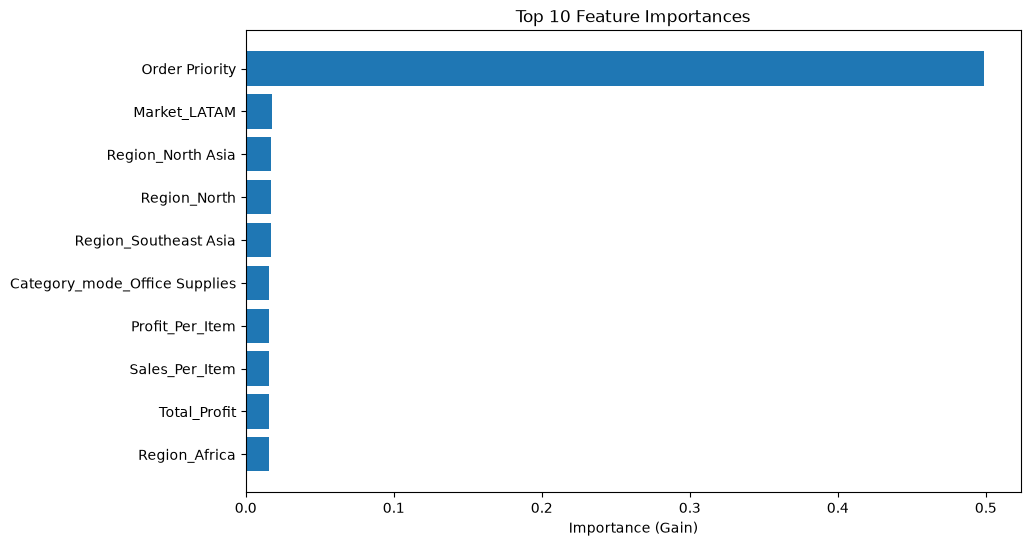

In [14]:
importances = models[model_names[2]]['model'].model.feature_importances_

importance_df = pd.DataFrame({
    'feature': models[model_names[2]]['model'].model.feature_names_in_,
    'importance': importances
}).sort_values('importance', ascending=False)
importance_df.to_csv("result_data/xgbclassifier_classification_feature_imp.csv", index=False)
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)['feature'], importance_df.head(10)['importance'])
plt.xlabel('Importance (Gain)')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [15]:
# elestic_result = models[model_names[1]]['model'].predict(regression_test_df)
# pd.DataFrame({
#         "y_true": elestic_result[0],
#         "y_predict": elestic_result[1]
# }).to_csv("result_data/elestic_regression_result.csv", index=False)

# xgb_result = models[model_names[2]]['model'].predict(regression_test_df)
# pd.DataFrame({
#         "y_true": xgb_result[0],
#         "y_predict": xgb_result[1]
# }).to_csv("result_data/xgb_regression_result.csv", index=False)